<a href="https://colab.research.google.com/github/luquelab/Flyby-Denial/blob/main/Kennedy_Kreutzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import io

# Upload your FASTA file
print("Please upload your FASTA file:")
uploaded = files.upload()

# Assuming you upload one file, get its name
for fn in uploaded.keys():
    fasta_filename = fn
    print(f'User uploaded file "{fasta_filename}" with length {len(uploaded[fn])} bytes')

# Read and parse the FASTA file without Biopython
sequences = []
current_sequence = {}

with io.StringIO(uploaded[fasta_filename].decode('utf-8')) as fasta_handle:
    for line in fasta_handle:
        line = line.strip()
        if not line: # Skip empty lines
            continue

        if line.startswith('>'):
            if current_sequence: # Save previous sequence if it exists
                sequences.append(current_sequence)

            # Start a new sequence record
            current_sequence = {"id": "", "description": "", "sequence": ""}

            header_parts = line[1:].split(None, 1) # Split at first whitespace for ID and description
            current_sequence["id"] = header_parts[0]
            if len(header_parts) > 1:
                current_sequence["description"] = header_parts[1]
            else:
                current_sequence["description"] = current_sequence["id"]
        else:
            # Append sequence line, removing any whitespace
            current_sequence["sequence"] += line.replace(' ', '')

    if current_sequence: # Add the last sequence after loop finishes
        sequences.append(current_sequence)

print(f"\nSuccessfully parsed {len(sequences)} sequences.")
print("\nFirst 5 sequences:")
for i, seq_record in enumerate(sequences[:5]):
    print(f"ID: {seq_record['id']}")
    print(f"Description: {seq_record['description']}")
    print(f"Sequence: {seq_record['sequence'][:50]}...\n") # Display first 50 chars of sequence


Please upload your FASTA file:


Saving B19_VP2_sequence.fasta to B19_VP2_sequence (1).fasta
User uploaded file "B19_VP2_sequence (1).fasta" with length 5729 bytes

Successfully parsed 5 sequences.

First 5 sequences:
ID: YP_009333215.1|Genotype_1a|United_States
Description: YP_009333215.1|Genotype_1a|United_States
Sequence: MSDTYGGASKHVWAEQGQQWANTVGPWWDWDDNMSADFNELLADLDSNLS...

ID: AFJ15638.1|Genotype_1b|Vietnam
Description: AFJ15638.1|Genotype_1b|Vietnam
Sequence: MSDTYGGASKHVWAEQGQQWANTVGPWWDWDDNMSADFNELLADLDSNLS...

ID: AY064476.1|Genotype_2|Germany
Description: AY064476.1|Genotype_2|Germany
Sequence: MSDTYGGASKHVWAEQGQQWANTVGPWWDWDDNMSADFNELLADLDSNLS...

ID: AX003421.1|Genotype_3a|France
Description: AX003421.1|Genotype_3a|France
Sequence: MSDTYGGASKHVWAEQGQQWANTVGPWWDWDDNMSADFNELLADLDSNLS...

ID: AY083234.1|Genotype_3b|Ghana
Description: AY083234.1|Genotype_3b|Ghana
Sequence: MSDTYGGASKHVWAEQGQQWANTVGPWWDWDDNMSADFNELLADLDSNLS...



### Physicochemical Properties

In [ ]:
# Molecular weights of standard amino acids (average mass, not monoisotopic)
# Source: https://www.sigmaaldrich.com/US/en/technical-documents/technical-article/protein-biology/protein-purification/peptide-molecular-weight-calculation
AA_MOL_WEIGHTS = {
    'A': 71.0788, 'R': 156.1875, 'N': 114.1038, 'D': 115.0886, 'C': 103.1448,
    'Q': 128.1307, 'E': 129.1155, 'G': 57.0519, 'H': 137.1411, 'I': 113.1594,
    'L': 113.1594, 'K': 128.1741, 'M': 131.1926, 'F': 147.1766, 'P': 97.1167,
    'S': 87.0782, 'T': 101.1051, 'W': 186.2132, 'Y': 163.1760, 'V': 99.1326
}

# Molecular weight of water (for peptide bond formation calculation)
H2O_MOL_WEIGHT = 18.01524

# Iterate through each sequence and calculate properties
for seq_record in sequences:
    protein_sequence = seq_record['sequence'].upper() # Ensure uppercase for consistent lookup

    # 1. Amino Acid Length
    seq_record['length'] = len(protein_sequence)

    # 2. Amino Acid Composition
    composition = {aa: protein_sequence.count(aa) for aa in AA_MOL_WEIGHTS.keys()}
    seq_record['composition'] = composition

    # 3. Molecular Weight (Daltons)
    # Sum of individual amino acid weights minus (number of peptide bonds * water weight)
    # Number of peptide bonds = length - 1
    molecular_weight = sum(AA_MOL_WEIGHTS.get(aa, 0) for aa in protein_sequence)
    if seq_record['length'] > 1:
        molecular_weight -= (seq_record['length'] - 1) * H2O_MOL_WEIGHT
    # Add the weight of water to the N-terminus and O to the C-terminus if considering intact protein
    # For simplicity here, we're doing the common 'sum of residues - (n-1)*H2O'
    # If the sequence is just a single amino acid, its weight is just the AA's weight + H2O for the ends
    elif seq_record['length'] == 1:
        molecular_weight += H2O_MOL_WEIGHT # Add water for the terminal H and OH

    seq_record['molecular_weight'] = round(molecular_weight, 2)

print("Calculated physicochemical properties for all sequences.")
print("\nFirst 5 sequences with new properties:")
for i, seq_record in enumerate(sequences[:5]):
    print(f"ID: {seq_record['id']}")
    print(f"Length: {seq_record['length']}")
    print(f"Molecular Weight: {seq_record['molecular_weight']:.2f} Da")
    print(f"Composition (partial): {{k: v for k, v in seq_record['composition'].items() if v > 0}}")
    print("---\n")

Calculated physicochemical properties for all sequences.

First 5 sequences with new properties:
ID: YP_009333215.1|Genotype_1a|United_States
Length: 1093
Molecular Weight: 117851.27 Da
Composition (partial): {k: v for k, v in seq_record['composition'].items() if v > 0}
---

ID: AFJ15638.1|Genotype_1b|Vietnam
Length: 1093
Molecular Weight: 117851.27 Da
Composition (partial): {k: v for k, v in seq_record['composition'].items() if v > 0}
---

ID: AY064476.1|Genotype_2|Germany
Length: 1093
Molecular Weight: 117851.27 Da
Composition (partial): {k: v for k, v in seq_record['composition'].items() if v > 0}
---

ID: AX003421.1|Genotype_3a|France
Length: 1093
Molecular Weight: 117851.27 Da
Composition (partial): {k: v for k, v in seq_record['composition'].items() if v > 0}
---

ID: AY083234.1|Genotype_3b|Ghana
Length: 1093
Molecular Weight: 117851.27 Da
Composition (partial): {k: v for k, v in seq_record['composition'].items() if v > 0}
---



### Sequence Similarity

To calculate pairwise sequence similarity, we will compute the percentage of identical amino acids between each unique pair of protein sequences. For simplicity, we'll align them greedily and divide the number of matches by the length of the shorter sequence in the pair. More sophisticated methods often involve dynamic programming algorithms (like Smith-Waterman or Needleman-Wunsch) or specialized tools, but this provides a basic measure of identity.

In [ ]:
from itertools import combinations

# A simple function to calculate sequence identity between two sequences
def calculate_sequence_identity(seq1, seq2):
    min_len = min(len(seq1), len(seq2))
    if min_len == 0: # Handle empty sequences to avoid division by zero
        return 0.0

    matches = 0
    for i in range(min_len):
        if seq1[i] == seq2[i]:
            matches += 1

    # Identity as percentage of matched residues over the shorter sequence length
    return (matches / min_len) * 100

# Store similarity results
similarity_results = []

# Iterate through all unique pairs of sequences
# Using 'combinations' ensures each pair is processed once and no self-comparison
for seq_record1, seq_record2 in combinations(sequences, 2):
    seq1 = seq_record1['sequence'].upper()
    seq2 = seq_record2['sequence'].upper()

    identity = calculate_sequence_identity(seq1, seq2)

    similarity_results.append({
        'id1': seq_record1['id'],
        'id2': seq_record2['id'],
        'similarity_percent': round(identity, 2)
    })

print("Calculated pairwise sequence similarities.")

# Display the first few similarity results
print("\nFirst 10 pairwise similarity results:")
for result in similarity_results[:10]:
    print(f"Sequence '{result['id1']}' and '{result['id2']}' have {result['similarity_percent']:.2f}% identity.")


Calculated pairwise sequence similarities.

First 10 pairwise similarity results:
Sequence 'YP_009333215.1|Genotype_1a|United_States' and 'AFJ15638.1|Genotype_1b|Vietnam' have 100.00% identity.
Sequence 'YP_009333215.1|Genotype_1a|United_States' and 'AY064476.1|Genotype_2|Germany' have 100.00% identity.
Sequence 'YP_009333215.1|Genotype_1a|United_States' and 'AX003421.1|Genotype_3a|France' have 100.00% identity.
Sequence 'YP_009333215.1|Genotype_1a|United_States' and 'AY083234.1|Genotype_3b|Ghana' have 100.00% identity.
Sequence 'AFJ15638.1|Genotype_1b|Vietnam' and 'AY064476.1|Genotype_2|Germany' have 100.00% identity.
Sequence 'AFJ15638.1|Genotype_1b|Vietnam' and 'AX003421.1|Genotype_3a|France' have 100.00% identity.
Sequence 'AFJ15638.1|Genotype_1b|Vietnam' and 'AY083234.1|Genotype_3b|Ghana' have 100.00% identity.
Sequence 'AY064476.1|Genotype_2|Germany' and 'AX003421.1|Genotype_3a|France' have 100.00% identity.
Sequence 'AY064476.1|Genotype_2|Germany' and 'AY083234.1|Genotype_3b|Gha

### Relationship between Proteins (Dendrograms)

To visualize the relationships between proteins, we will use hierarchical clustering and represent the results as dendrograms. This will allow us to see how sequences group together based on different criteria: physicochemical properties, sequence similarity, and a combination of both.

/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:2947: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, dvw])
/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:2947: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, dvw])
/usr/local/lib/python3.12/dist-packages/scipy/cluster/hierarchy.py:2947: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, dvw])


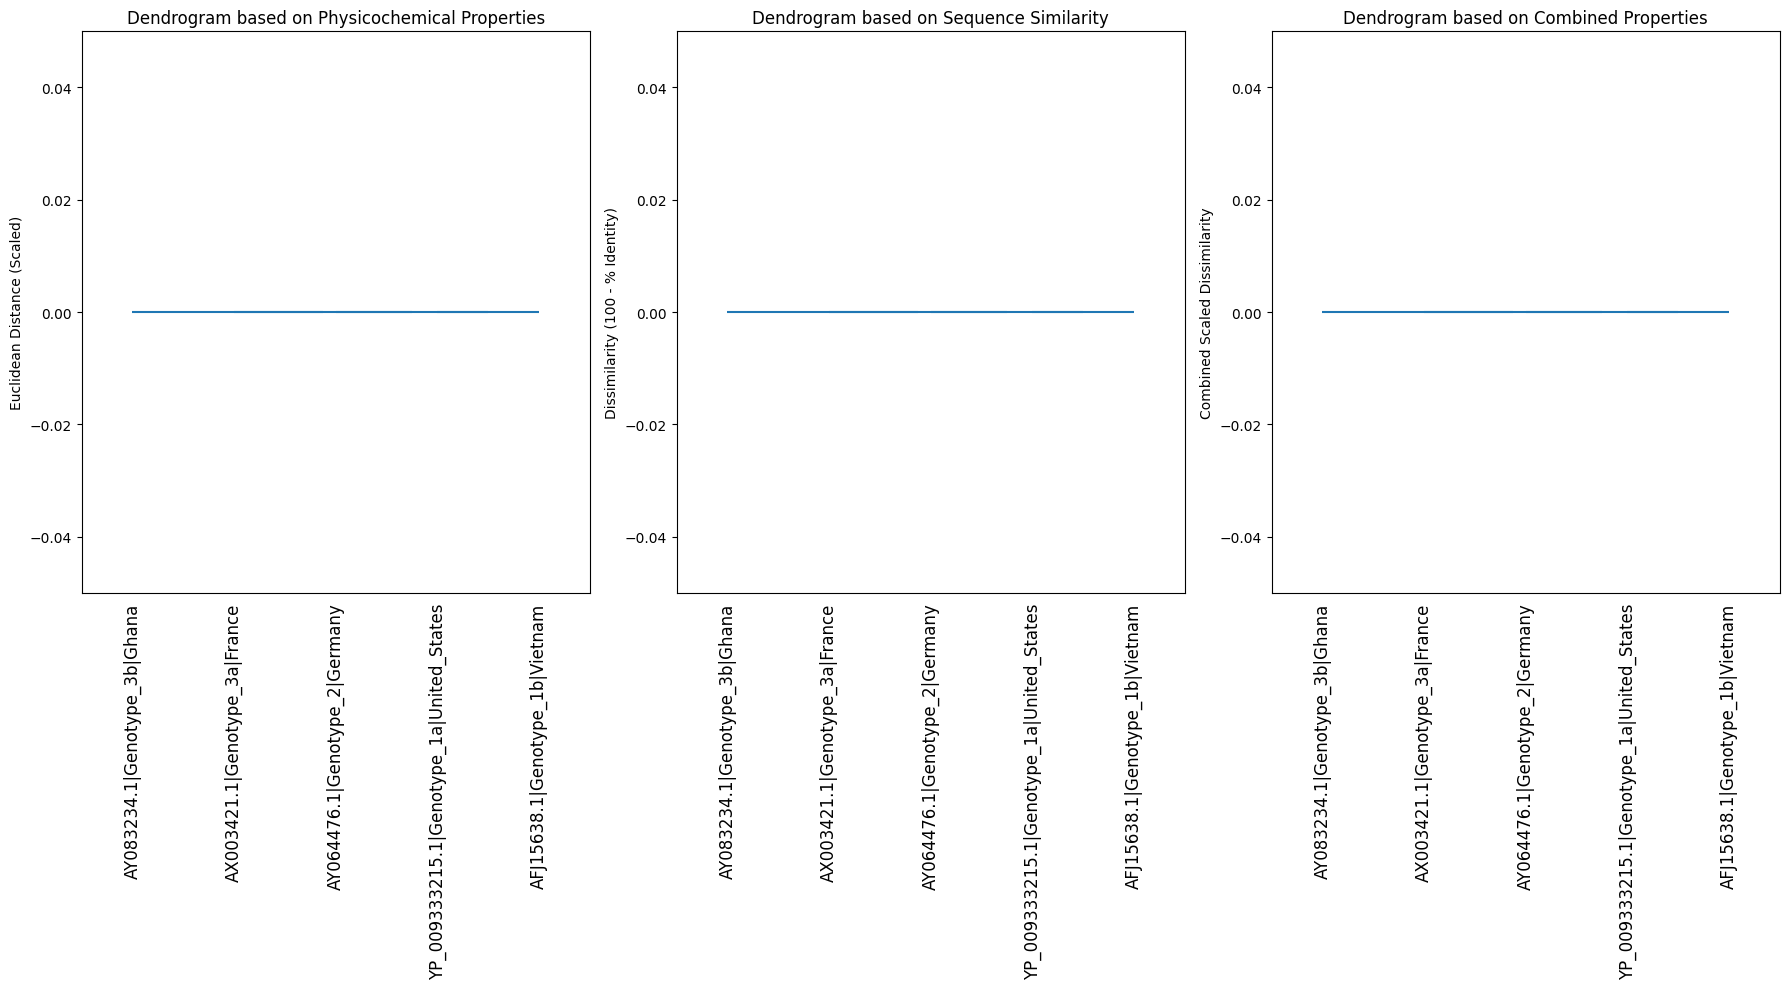

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# --- 1. Prepare Data for Physicochemical Properties ---

# Extract physicochemical properties into a DataFrame
physchem_data = []
sequence_ids = []
for seq_record in sequences:
    row = [seq_record['length'], seq_record['molecular_weight']]
    # Add amino acid counts from composition
    for aa_count in seq_record['composition'].values():
        row.append(aa_count)
    physchem_data.append(row)
    sequence_ids.append(seq_record['id'])

physchem_df = pd.DataFrame(physchem_data, index=sequence_ids)

# Standardize the data (important for distance calculations where features have different scales)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
physchem_scaled = scaler.fit_transform(physchem_df)

# Calculate Euclidean distance matrix for physicochemical properties
dist_physchem = pdist(physchem_scaled, metric='euclidean')

# --- 2. Prepare Data for Sequence Similarity ---

# Create a dictionary for quick lookup of similarity by pair
similarity_dict = {}
for res in similarity_results:
    # Store both (id1, id2) and (id2, id1) for easy lookup, ensure order for consistency
    key1 = tuple(sorted((res['id1'], res['id2'])))
    similarity_dict[key1] = res['similarity_percent']

# Create an N x N distance matrix from similarity percentages
num_sequences = len(sequence_ids)
dist_seq_sim_matrix = np.zeros((num_sequences, num_sequences))

for i in range(num_sequences):
    for j in range(num_sequences):
        if i == j:
            dist_seq_sim_matrix[i, j] = 0.0 # Distance to self is 0
        else:
            id1 = sequence_ids[i]
            id2 = sequence_ids[j]
            key = tuple(sorted((id1, id2)))
            # Convert similarity percentage to dissimilarity (distance)
            # 100 - similarity for percentage, or 1 - (similarity/100) for fraction
            dist_seq_sim_matrix[i, j] = 100.0 - similarity_dict.get(key, 0.0) # Assume 0% sim if not found

# Convert square matrix to condensed distance vector required by linkage
dist_seq_sim = squareform(dist_seq_sim_matrix)

# --- 3. Combine Distance Matrices ---

# Scale both distance vectors to a similar range (e.g., 0 to 1)
# This is important before combining them

# Handle cases where min and max are the same (e.g., all distances are 0)
if (dist_physchem.max() - dist_physchem.min()) == 0:
    dist_physchem_scaled_norm = np.zeros_like(dist_physchem)
else:
    dist_physchem_scaled_norm = (dist_physchem - dist_physchem.min()) / (dist_physchem.max() - dist_physchem.min())

if (dist_seq_sim.max() - dist_seq_sim.min()) == 0:
    dist_seq_sim_scaled_norm = np.zeros_like(dist_seq_sim)
else:
    dist_seq_sim_scaled_norm = (dist_seq_sim - dist_seq_sim.min()) / (dist_seq_sim.max() - dist_seq_sim.min())

# Combine the scaled distances (e.g., by simple averaging)
dist_combined = (dist_physchem_scaled_norm + dist_seq_sim_scaled_norm) / 2

# --- Perform Hierarchical Clustering and Plot Dendrograms ---

plt.figure(figsize=(18, 10))

# Dendrogram 1: Physicochemical Properties
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
linkage_physchem = linkage(dist_physchem, method='average')
dendrogram(linkage_physchem, labels=sequence_ids, orientation='top', leaf_rotation=90)
plt.title('Dendrogram based on Physicochemical Properties')
plt.ylabel('Euclidean Distance (Scaled)')

# Dendrogram 2: Sequence Similarity
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
linkage_seq_sim = linkage(dist_seq_sim, method='average')
dendrogram(linkage_seq_sim, labels=sequence_ids, orientation='top', leaf_rotation=90)
plt.title('Dendrogram based on Sequence Similarity')
plt.ylabel('Dissimilarity (100 - % Identity)')

# Dendrogram 3: Combined Properties
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
linkage_combined = linkage(dist_combined, method='average')
dendrogram(linkage_combined, labels=sequence_ids, orientation='top', leaf_rotation=90)
plt.title('Dendrogram based on Combined Properties')
plt.ylabel('Combined Scaled Dissimilarity')

plt.tight_layout()
plt.show()


### Exporting Results to Files

We can save the calculated physicochemical properties and the pairwise sequence similarities into separate files (e.g., CSV) for easy storage, sharing, or further analysis. After generating the files, you can download them directly from Google Colab.

In [ ]:
import pandas as pd
from google.colab import files

# --- 1. Export Physicochemical Properties ---
print("\nExporting Physicochemical Properties...")

# Prepare data for DataFrame
physchem_export_data = []
for seq_record in sequences:
    row = {
        'ID': seq_record['id'],
        'Description': seq_record['description'],
        'Length': seq_record['length'],
        'Molecular_Weight': seq_record['molecular_weight']
    }
    # Add amino acid composition as separate columns
    for aa, count in seq_record['composition'].items():
        row[f'AA_{aa}_Count'] = count
    physchem_export_data.append(row)

physchem_df_export = pd.DataFrame(physchem_export_data)
physchem_output_filename = 'protein_physicochemical_properties.csv'
physchem_df_export.to_csv(physchem_output_filename, index=False)
print(f"Physicochemical properties saved to {physchem_output_filename}")

# --- 2. Export Sequence Similarity Results ---
print("\nExporting Sequence Similarity Results...")
similarity_df_export = pd.DataFrame(similarity_results)
similarity_output_filename = 'protein_sequence_similarities.csv'
similarity_df_export.to_csv(similarity_output_filename, index=False)
print(f"Sequence similarity results saved to {similarity_output_filename}")

print("\n--- Files Created --- ")
print(f"You can now download '{physchem_output_filename}' and '{similarity_output_filename}'.")
print("Click on the 'Files' icon on the left sidebar (folder icon), then right-click on the filenames to download them to your local computer.")

# Optional: Directly trigger download in Colab (can be annoying if many files or large files)
# files.download(physchem_output_filename)
# files.download(similarity_output_filename)



Exporting Physicochemical Properties...
Physicochemical properties saved to protein_physicochemical_properties.csv

Exporting Sequence Similarity Results...
Sequence similarity results saved to protein_sequence_similarities.csv

--- Files Created --- 
You can now download 'protein_physicochemical_properties.csv' and 'protein_sequence_similarities.csv'.
Click on the 'Files' icon on the left sidebar (folder icon), then right-click on the filenames to download them to your local computer.
